# Run ACS forward model with archNEMESIS

In this notebook, we are going to show how to use the *acs* Python package to run forward models for the ACS solar occultation observations using the archNEMESIS radiative transfer algorithm. 

In [1]:
import acs 
import archnemesis as ans
import numpy as np
import matplotlib.pyplot as plt

## 1. Creating reference classes

First of all, we need to create the input reference classes. This can be easily done using the functionality implemented within the *acs.archnemesis* Python files. 

For the solar occultations, many of the reference classes can be neglected or are not important. In this example, we show how to create the most essential classes, that include the reference atmosphere, the measurement characteristics, and the absorption cross sections required to model the absorption of the different gases.

### 1.1. Atmosphere

We are going to create a reference atmosphere from the Mars Climate Database, and we are then going to split CO$_2$ into its main four isotopes. 

In [2]:
lat = 0. ; lon = 0. ; Ls = 90. ; LST =18.
h = np.linspace(0.,100.,51)

In [3]:
#Creating Atmosphere from Mars Climate Database
Atmosphere = acs.archnemesis.atmosphere.create_mcd_atmosphere_class(lat,lon,Ls,LST,h)

#Splitting CO2 into its 4 main isotopes
Atmosphere = acs.archnemesis.atmosphere.split_CO2_isotopes(Atmosphere)

 Loading variables for new season
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_03_me.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_03_sd.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_03_thermo_ave_me.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_03_thermo_ave_sd.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_04_me.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_04_sd.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_04_thermo_ave_me.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/clim_aveEUV/clim_04_thermo_ave_sd.nc
 Loading new mean variable
 Loading gravity field coefficients from file /srv/workspace/data/mcd/MCD_6.1/data/mgm1025
 Loading MOLA topography from file /srv/workspace/data/mcd/MCD_6.1/data/mola32.nc
 Done reading MOLA data
 Opening /srv/workspace/data/mcd/MCD_6.1/data/slope_map.nc
 Opening /srv/workspace/data/mcd/MCD_6.1/data/dust_high_resol/d

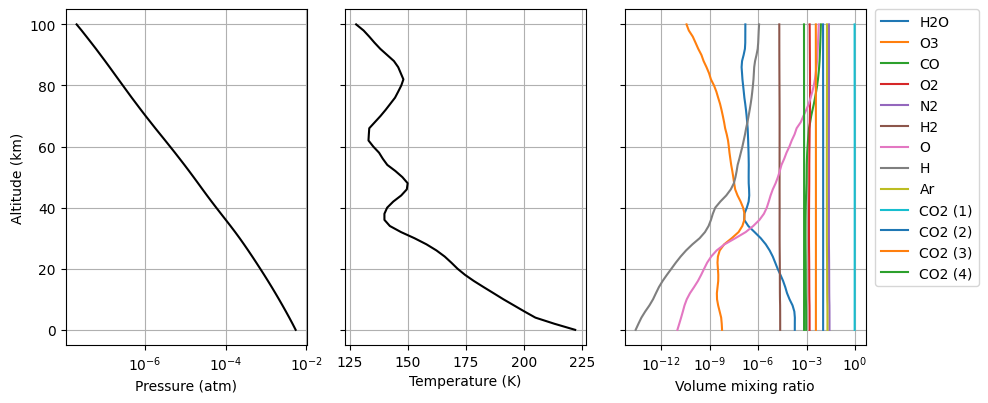

In [4]:
Atmosphere.plot_Atm()

### 1.2. Measurement

In [17]:
#tangent_heights = np.array([0.,10.,20.,30.,40.])  #Tangent heights in km
tangent_heights = np.arange(0.,80.,10.)
wavemin = 6700.  #Minimum wavenumber (cm-1)
wavemax = 6780.  #Maximum wavenumber (cm-1)

resolving_power = 20000.  #Resolving power (R = nu/delta_nu)

In [18]:
Measurement = acs.archnemesis.measurement.create_measurement_forward_model(
    lat,
    lon,
    tangent_heights,
    wavemin,
    wavemax,
    resolving_power=resolving_power,
    nwave_per_fwhm=3,
    )

### 1.3. Spectroscopy

In this case, we are going to take the absorption cross sections from pre-tabulated look-up tables to make the calculations faster.

In [19]:
#Defining the path to the line-by-line look-up tables
lbl_tables = ["/srv/workspace/data/nemesis/spectroscopy/lbltables/acsnir/archnem/co2_iso1_acsnir_order52.h5",
              "/srv/workspace/data/nemesis/spectroscopy/lbltables/acsnir/archnem/co2_iso2_acsnir_order52.h5"]

In [20]:
Spectroscopy = acs.archnemesis.spectroscopy.create_spectroscopy_lookup_class(lbl_tables)

## 2. Creating archNEMESIS input file

Once we have defined the essential input classes, we can write the archNEMESIS file. We will create this file using the *acs.archnemesis.files.create_files_forward_model* function - that way, the rest of the classes will be created using default values valid for the ACS solar occultation observations.

In [21]:
filename = "example_nir_co2_isotopes_lookup"

In [22]:
acs.archnemesis.files.create_files_forward_model(filename,Atmosphere,Measurement,Spectroscopy)

## 3. Running forward model

Once we have created the input file, we can read it using the archNEMESIS package, and run a forward model simulation specific for solar occultation observations (i.e., *nemesisSOfm*).

In [23]:
#Reading the input files
Atmosphere,Measurement,Spectroscopy,Scatter,Stellar,Surface,CIA,Layer,Variables,Retrieval,Telluric = ans.Files.read_input_files_hdf5(filename)

INFO :: read_apr :: Variables_0.py-823 :: 
Variables_0 :: read_apr :: varident [0 0 2]. Constructed model "Model2" (id=2)
INFO :: read_apr :: Variables_0.py-826 ::   Model2:
  |- id : 2
  |- parent classes: PreRTModelBase
  |- description: In this model, the atmospheric parameters are scaled using a
  |               single factor with  respect to the vertical profiles in the
  |               reference atmosphere
  |- n_state_vector_entries : 1
  |- state_vector_slice : slice(0, 1, None)
  |- state_vector_start : 0
  |- target : 1
  |- Parameters:
  |  |- scaling_factor :
  |  |  |- slice : slice(0, 1, None)
  |  |  |- unit : PROFILE_TYPE
  |  |  |- description: Scaling factor applied to the reference profile
  |  |  |- apriori value : 1.0


In [24]:
#Running forward model
ForwardModel = ans.ForwardModel_0(Atmosphere=Atmosphere,Surface=Surface,Measurement=Measurement,Spectroscopy=Spectroscopy,Stellar=Stellar,Scatter=Scatter,CIA=CIA,Layer=Layer,Variables=Variables)
SPECONV = ForwardModel.nemesisSOfm()

INFO :: nemesisSOfm :: ForwardModel_0.py-915 :: Calculating forward model for solar occultation observation
INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: calculate_vertical_cia_opacity :: ForwardModel_0.py-3897 :: self.CIAX not included in calculations
INFO :: calculate_layer_opacity :: ForwardModel_0.py-3968 :: CIRSrad :: Aerosol optical depths at  (np.float64(6699.392), ' :: ', array([], dtype=float64))
INFO :: calculate_layer_opacity :: ForwardModel_0.py-3986 :: Calculating TOTAL opacity
INFO :: calculate_layer_opacity :: ForwardModel_0.py-4003 :: CIRSradg :: Calculating TOTAL line-of-sight opacity
INFO :: CIRSrad :: ForwardModel_0.py-4468 :: CIRSrad :: IMODM = <PathCalcEnum.PLANCK_FUNCTION_AT_BIN_CENTRE: 8192>
INFO :: nemesisSOfm :: ForwardModel_0.py-965 :: Convolving spectra and gradients with instrument line shape


## 4. Plotting the results

Now, we can plot the simulated transmission spectra.

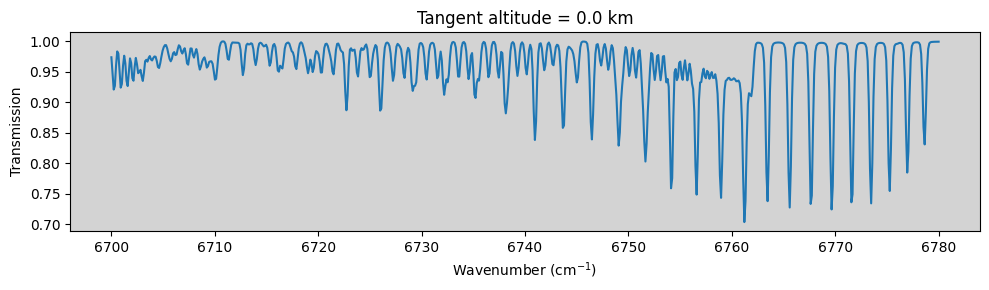

In [25]:
igeom = 0

fig,ax1 = plt.subplots(1,1,figsize=(10,3))
ax1.plot(Measurement.VCONV[:,igeom],SPECONV[:,igeom],c='tab:blue')
ax1.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax1.set_ylabel('Transmission')
ax1.set_facecolor('lightgray')
ax1.set_title(f"Tangent altitude = {Measurement.TANHE[igeom,0]} km")
plt.tight_layout()

## 5. Adding synthetic noise

Optionally, we can add synthetic noise to the spectra to make it more realistic and potentially use it for synthetic retrievals.

In [26]:
#Signal-to-noise ratio to use for the synthetic spectra
snr = 300.

noise_level = 1. / snr

# Add Gaussian noise
noise = np.random.normal(0, noise_level, size=SPECONV.shape)
noisy_spectrum = SPECONV + noise

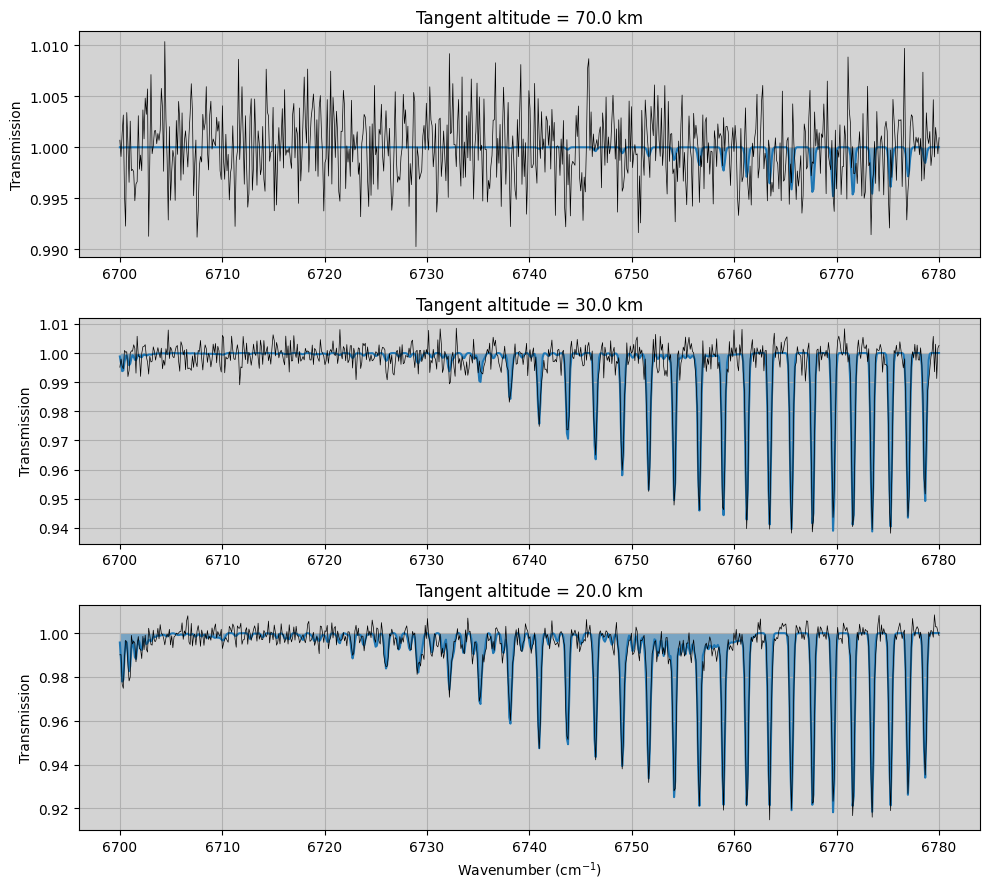

In [27]:
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(10,9))

#First geometry
igeom1 = -1
ax1.fill_between(Measurement.VCONV[:,igeom1],SPECONV[:,igeom1],np.ones(Measurement.NCONV[igeom1]),alpha=0.5)
ax1.plot(Measurement.VCONV[:,igeom1],SPECONV[:,igeom1])
ax1.plot(Measurement.VCONV[:,igeom1],noisy_spectrum[:,igeom1],c='black',linewidth=0.5)
ax1.set_facecolor('lightgray')
ax1.grid()
ax1.set_title('Tangent altitude = '+str(Measurement.TANHE[igeom1,0])+' km')
ax1.set_ylabel('Transmission')

#Second geometry
igeom2 = -5
ax2.fill_between(Measurement.VCONV[:,igeom2],SPECONV[:,igeom2],np.ones(Measurement.NCONV[igeom2]),alpha=0.5)
ax2.plot(Measurement.VCONV[:,igeom2],SPECONV[:,igeom2])
ax2.plot(Measurement.VCONV[:,igeom2],noisy_spectrum[:,igeom2],c='black',linewidth=0.5)
ax2.set_facecolor('lightgray')
ax2.grid()
ax2.set_title('Tangent altitude = '+str(Measurement.TANHE[igeom2,0])+' km')
ax2.set_ylabel('Transmission')


#Third geometry
igeom3 = 2
ax3.fill_between(Measurement.VCONV[:,igeom3],SPECONV[:,igeom3],np.ones(Measurement.NCONV[igeom3]),alpha=0.5)
ax3.plot(Measurement.VCONV[:,igeom3],SPECONV[:,igeom3])
ax3.plot(Measurement.VCONV[:,igeom3],noisy_spectrum[:,igeom3],c='black',linewidth=0.5)
ax3.set_facecolor('lightgray')
ax3.grid()
ax3.set_title('Tangent altitude = '+str(Measurement.TANHE[igeom3,0])+' km')
ax3.set_ylabel('Transmission')
ax3.set_xlabel('Wavenumber (cm$^{-1}$)')

plt.tight_layout()

## 6. Writing synthetic spectrum to file

Now, we can write the synthetic spectra to a HDF5 file so that we can use it in synthetic retrievals in the future. 

In [28]:
Measurement.edit_MEAS(noisy_spectrum)
Measurement.edit_ERRMEAS(np.ones(SPECONV.shape) * noise_level)
Measurement.write_hdf5(filename)